In [92]:
import numpy as np
import matplotlib.pyplot as plt
import catboost
import lightgbm
import pandas as pd
import xgboost
import tensorflow as tf
pd.set_option('display.max_columns', None)


In [93]:
# load test.csv and train.csv as pandas dataframes
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [94]:
train.head(), train.shape, test.head(), test.shape

(   id        date country              store             product  num_sold
 0   0  2010-01-01  Canada  Discount Stickers   Holographic Goose       NaN
 1   1  2010-01-01  Canada  Discount Stickers              Kaggle     973.0
 2   2  2010-01-01  Canada  Discount Stickers        Kaggle Tiers     906.0
 3   3  2010-01-01  Canada  Discount Stickers            Kerneler     423.0
 4   4  2010-01-01  Canada  Discount Stickers  Kerneler Dark Mode     491.0,
 (230130, 6),
        id        date country              store             product
 0  230130  2017-01-01  Canada  Discount Stickers   Holographic Goose
 1  230131  2017-01-01  Canada  Discount Stickers              Kaggle
 2  230132  2017-01-01  Canada  Discount Stickers        Kaggle Tiers
 3  230133  2017-01-01  Canada  Discount Stickers            Kerneler
 4  230134  2017-01-01  Canada  Discount Stickers  Kerneler Dark Mode,
 (98550, 5))

In [95]:
# find all unique values in all columns and also the count of unique values
for col in train.columns:
    print(col, train[col].nunique())
    print(train[col].unique())
    print("dtype: ", train[col].dtype)
    print("")

id 230130
[     0      1      2 ... 230127 230128 230129]
dtype:  int64

date 2557
['2010-01-01' '2010-01-02' '2010-01-03' ... '2016-12-29' '2016-12-30'
 '2016-12-31']
dtype:  object

country 6
['Canada' 'Finland' 'Italy' 'Kenya' 'Norway' 'Singapore']
dtype:  object

store 3
['Discount Stickers' 'Stickers for Less' 'Premium Sticker Mart']
dtype:  object

product 5
['Holographic Goose' 'Kaggle' 'Kaggle Tiers' 'Kerneler'
 'Kerneler Dark Mode']
dtype:  object

num_sold 4037
[  nan  973.  906. ... 3446. 2266. 3996.]
dtype:  float64



In [96]:
#print how mnay have num_sold as 0 or nan
print(train[train['num_sold'].isnull() | (train['num_sold'] == 0)].shape)
#print how mnay have any column as nan or a string col as empty or id col as nan or date col as empty
print(train[train.isnull().any(axis=1) | (train['id'].isnull()) | (train['date'].str.len() == 0)].shape)

# show head of all records where num_sold is 0 or nan
train[train['num_sold'].isnull() | (train['num_sold'] == 0)].head()



(8871, 6)
(8871, 6)


,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
45,45,2010-01-01,Kenya,Discount Stickers,Holographic Goose,NaN
90,90,2010-01-02,Canada,Discount Stickers,Holographic Goose,NaN
135,135,2010-01-02,Kenya,Discount Stickers,Holographic Goose,NaN
180,180,2010-01-03,Canada,Discount Stickers,Holographic Goose,NaN


In [97]:
import pandas as pd
import holidays
from datetime import datetime

# Assuming train and country DataFrames are already defined
# train = pd.read_csv('path_to_train.csv')
# country = pd.read_csv('path_to_country.csv')
#parse the 'date' column as datetime 
train['date'] = pd.to_datetime(train['date'])
# Country mapping dictionary
country_mapping = {
    'Canada': 'CA',
    'Finland': 'FI',
    'Italy': 'IT',
    'Kenya': 'KE',
    'Norway': 'NO',
    'Singapore': 'SG'
}

def is_holiday(date, country_name):
    country_code = country_mapping.get(country_name)
    if country_code:
        country_holidays = holidays.CountryHoliday(country_code)
        return date in country_holidays
    return False

def get_season(date):
    month = date.month
    day = date.day
    if (month == 12 and day >= 21) or (month in [1, 2]) or (month == 3 and day < 20):
        return 'Winter'
    elif (month == 3 and day >= 20) or (month in [4, 5]) or (month == 6 and day < 21):
        return 'Spring'
    elif (month == 6 and day >= 21) or (month in [7, 8]) or (month == 9 and day < 22):
        return 'Summer'
    else:
        return 'Fall'

train['is_holiday'] = train.apply(lambda row: is_holiday(row['date'], row['country']), axis=1)
train['season'] = train['date'].apply(lambda x: get_season(pd.to_datetime(x)))
train['saturday'] = train['date'].apply(lambda x: x.weekday() == 5)
train['sunday'] = train['date'].apply(lambda x: x.weekday() == 6)


# print("how many have saturday as True: ", train[train['saturday'] == True].shape)
# print("how many have sunday as True: ", train[train['sunday'] == True].shape)
# print("unique values in season: ", train['season'].unique())
train.head()

,id,date,country,store,product,num_sold,is_holiday,season,saturday,sunday
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN,True,Winter,False,False
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0,True,Winter,False,False
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0,True,Winter,False,False
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0,True,Winter,False,False
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0,True,Winter,False,False


In [98]:
import pandas as pd

categorical_columns = ['country', 'store', 'product', 'is_holiday', 'season', 'saturday', 'sunday']
numerical_columns = ['num_sold']
# train = pd.get_dummies(train, columns=categorical_columns)
# Function to combine categorical columns and hash the result
num_buckets = 2000
def combined_hash(row):
    combined_string = ''.join([str(row[col]) for col in categorical_columns])
    x=  hash(combined_string)
    if(x<0):
        x%=(-num_buckets)
    else:
        x%=num_buckets
    return x 
    

# Apply the function to each row and create a new column 'hash_col'
print(train.shape)
train['hash_col'] = train.apply(combined_hash, axis=1)
print(train.shape)
print("unique values in hash_col: ", train['hash_col'].nunique())
print("range of values in hash_col: ", train['hash_col'].min(), train['hash_col'].max())
train.head()
#apply one hot encoding to the categorical columns
train = pd.get_dummies(train, columns=categorical_columns)
print(train.shape)

(230130, 10)
(230130, 11)
unique values in hash_col:  1516
range of values in hash_col:  -1996 1997
(230130, 28)


In [99]:
# aaply ordinal  transformation to the date column
train['date'] = pd.to_datetime(train['date'])
train['date'] = train['date'].apply(lambda x: x.toordinal())
print(train.shape)
train.head()

#apply sin cos transformation to the date column by using which date of the year out of 365 days can be represented as sin and cos
train['sin_date'] = np.sin(2 * np.pi * train['date'] / 365)
train['cos_date'] = np.cos(2 * np.pi * train['date'] / 365)
print(train.shape)
train.head()



(230130, 28)
(230130, 30)


,id,date,num_sold,hash_col,country_Canada,country_Finland,country_Italy,country_Kenya,country_Norway,country_Singapore,store_Discount Stickers,store_Premium Sticker Mart,store_Stickers for Less,product_Holographic Goose,product_Kaggle,product_Kaggle Tiers,product_Kerneler,product_Kerneler Dark Mode,is_holiday_False,is_holiday_True,season_Fall,season_Spring,season_Summer,season_Winter,saturday_False,saturday_True,sunday_False,sunday_True,sin_date,cos_date
0,0,733773,NaN,-1669,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,True,False,True,False,0.854322,-0.519744
1,1,733773,973.0,-1548,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,True,False,True,False,0.854322,-0.519744
2,2,733773,906.0,1991,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,True,False,0.854322,-0.519744
3,3,733773,423.0,-1209,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,True,True,False,True,False,0.854322,-0.519744
4,4,733773,491.0,-255,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,True,True,False,True,False,0.854322,-0.519744


In [100]:
#remove all records where num_sold is nan and store those nan records in a new dataframe called nan_df
nan_df = train[train['num_sold'].isnull()]
print("shape of nan_df: ", nan_df.shape)
#remove nan_df from train
print("shape of train before removing nan_df", train.shape)
train = train.drop(nan_df.index)
print("shape of train after removing nan_df", train.shape)

shape of nan_df:  (8871, 30)
shape of train before removing nan_df (230130, 30)
shape of train after removing nan_df (221259, 30)


In [101]:
nan_df.shape,nan_df.head()

((8871, 30),
       id    date  num_sold  hash_col  country_Canada  country_Finland  \
 0      0  733773       NaN     -1669            True            False   
 45    45  733773       NaN     -1745           False            False   
 90    90  733774       NaN      1258            True            False   
 135  135  733774       NaN     -1779           False            False   
 180  180  733775       NaN     -1776            True            False   
 
      country_Italy  country_Kenya  country_Norway  country_Singapore  \
 0            False          False           False              False   
 45           False           True           False              False   
 90           False          False           False              False   
 135          False           True           False              False   
 180          False          False           False              False   
 
      store_Discount Stickers  store_Premium Sticker Mart  \
 0                       True           

In [102]:
train.head()
traincopy = train.copy()

In [107]:
import optuna
import xgboost as xgb
import catboost as cat
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import train_test_split

def objective(trial, train, model_type):
    # Make a copy of train
    train.drop(columns=['date', 'id'], inplace=True)
    max_leafes = 1200
    max_depth = 25
    # Define hyperparameters to tune
    if model_type == 'xgb':
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, max_leafes),
            'max_depth': trial.suggest_int('max_depth', 3, max_depth),
            'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True),
            'random_state': 42
        }
        model = xgb.XGBRegressor(**param)
    elif model_type == 'cat':
        param = {
            'iterations': trial.suggest_int('iterations', 100, max_leafes),
            'depth': trial.suggest_int('depth', 4, max_depth),
            'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True),
            'random_seed': 42,
            'silent': True
        }
        model = cat.CatBoostRegressor(**param)
    elif model_type == 'lgbm':
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, max_leafes),
            'max_depth': trial.suggest_int('max_depth', 3, max_depth),
            'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True),
            'random_state': 42
        }
        model = lgb.LGBMRegressor(**param)
    else:
        raise ValueError("Invalid model type. Choose from 'xgb', 'cat', or 'lgbm'.")
    
    # Split the data
    X_train, X_valid, y_train, y_valid = train_test_split(train.drop(['num_sold'], axis=1), train['num_sold'], test_size=0.2, random_state=42)
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Perform prediction
    predictions = model.predict(X_valid)
    
    # Calculate MAPE
    mape = mean_absolute_percentage_error(y_valid, predictions)
    
    return mape

def train_and_predict(train, model_type):
    # Optimize hyperparameters with Optuna
    study = optuna.create_study(direction='minimize')
    study.optimize(lambda trial: objective(trial, train.copy(), model_type), n_trials=2)
    
    print(f'Best hyperparameters: {study.best_params}')
    
    # Train the model with the best hyperparameters
    best_params = study.best_params
    if model_type == 'xgb':
        model = xgb.XGBRegressor(**best_params)
    elif model_type == 'cat':
        model = cat.CatBoostRegressor(**best_params)
    elif model_type == 'lgbm':
        model = lgb.LGBMRegressor(**best_params)
    
    date_column = train['date']
    id_column = train['id']
    train.drop(columns=['date', 'id'], inplace=True)
    if model_type == 'cat' or model_type=='xgb':
        model.fit(train.drop(['num_sold'], axis=1), train['num_sold'] ,verbose=False)
    else:
        model.fit(train.drop(['num_sold'], axis=1), train['num_sold'])

    
    train['date'] = date_column
    train['id'] = id_column
    
    date_column = train['date']
    id_column = train['id']
    num_sold_actual = train['num_sold']
    train.drop(columns=['date', 'id', 'num_sold'], inplace=True)
    
    predictions = model.predict(train)
    
    decimal_found = False
    fractional_sum = 0
    for pred in predictions:
        fractional_part = pred - int(pred)
        if fractional_part != 0:
            decimal_found = True
            fractional_sum += fractional_part
    
    if decimal_found:
        print("There was a decimal number in the predictions.")
    print(f'Sum of all fractional parts: {fractional_sum}')
    
    predictions = [round(pred) for pred in predictions]
    
    train['date'] = date_column
    train['id'] = id_column
    train['num_sold'] = num_sold_actual
    
    mape = mean_absolute_percentage_error(num_sold_actual, predictions)
    print(f'Mean Absolute Percentage Error: {mape}')
    
    plt.figure(figsize=(15, 15))
    
    plt.subplot(3, 1, 1)
    plt.plot(train['id'], num_sold_actual, label='Actual num_sold')
    plt.plot(train['id'], predictions, label='Predicted num_sold', linestyle='--')
    plt.xlabel('id')
    plt.ylabel('Number Sold')
    plt.title('Actual vs Predicted Number Sold')
    plt.legend()
    
    plt.subplot(3, 1, 2)
    plt.plot(train['id'], num_sold_actual, label='Actual num_sold', color='blue')
    plt.xlabel('id')
    plt.ylabel('Number Sold')
    plt.title('Actual Number Sold')
    plt.legend()
    
    plt.subplot(3, 1, 3)
    plt.plot(train['id'], predictions, label='Predicted num_sold', color='orange', linestyle='--')
    plt.xlabel('id')
    plt.ylabel('Number Sold')
    plt.title('Predicted Number Sold')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    train = traincopy.copy()

# Example usage
# train_and_predict(train_data, 'xgb')

[I 2025-01-14 09:32:03,679] A new study created in memory with name: no-name-84f550c1-37ec-4810-921c-44df34bf5d7c
[I 2025-01-14 09:32:12,989] Trial 0 finished with value: 0.1642157910849387 and parameters: {'n_estimators': 980, 'max_depth': 7, 'learning_rate': 0.005137901499192744}. Best is trial 0 with value: 0.1642157910849387.
[I 2025-01-14 09:32:25,339] Trial 1 finished with value: 0.11598880402460143 and parameters: {'n_estimators': 271, 'max_depth': 14, 'learning_rate': 0.06127745303201989}. Best is trial 1 with value: 0.11598880402460143.


Best hyperparameters: {'n_estimators': 271, 'max_depth': 14, 'learning_rate': 0.06127745303201989}
There was a decimal number in the predictions.
Sum of all fractional parts: 110412.45848160423
Mean Absolute Percentage Error: 0.08829791618831921


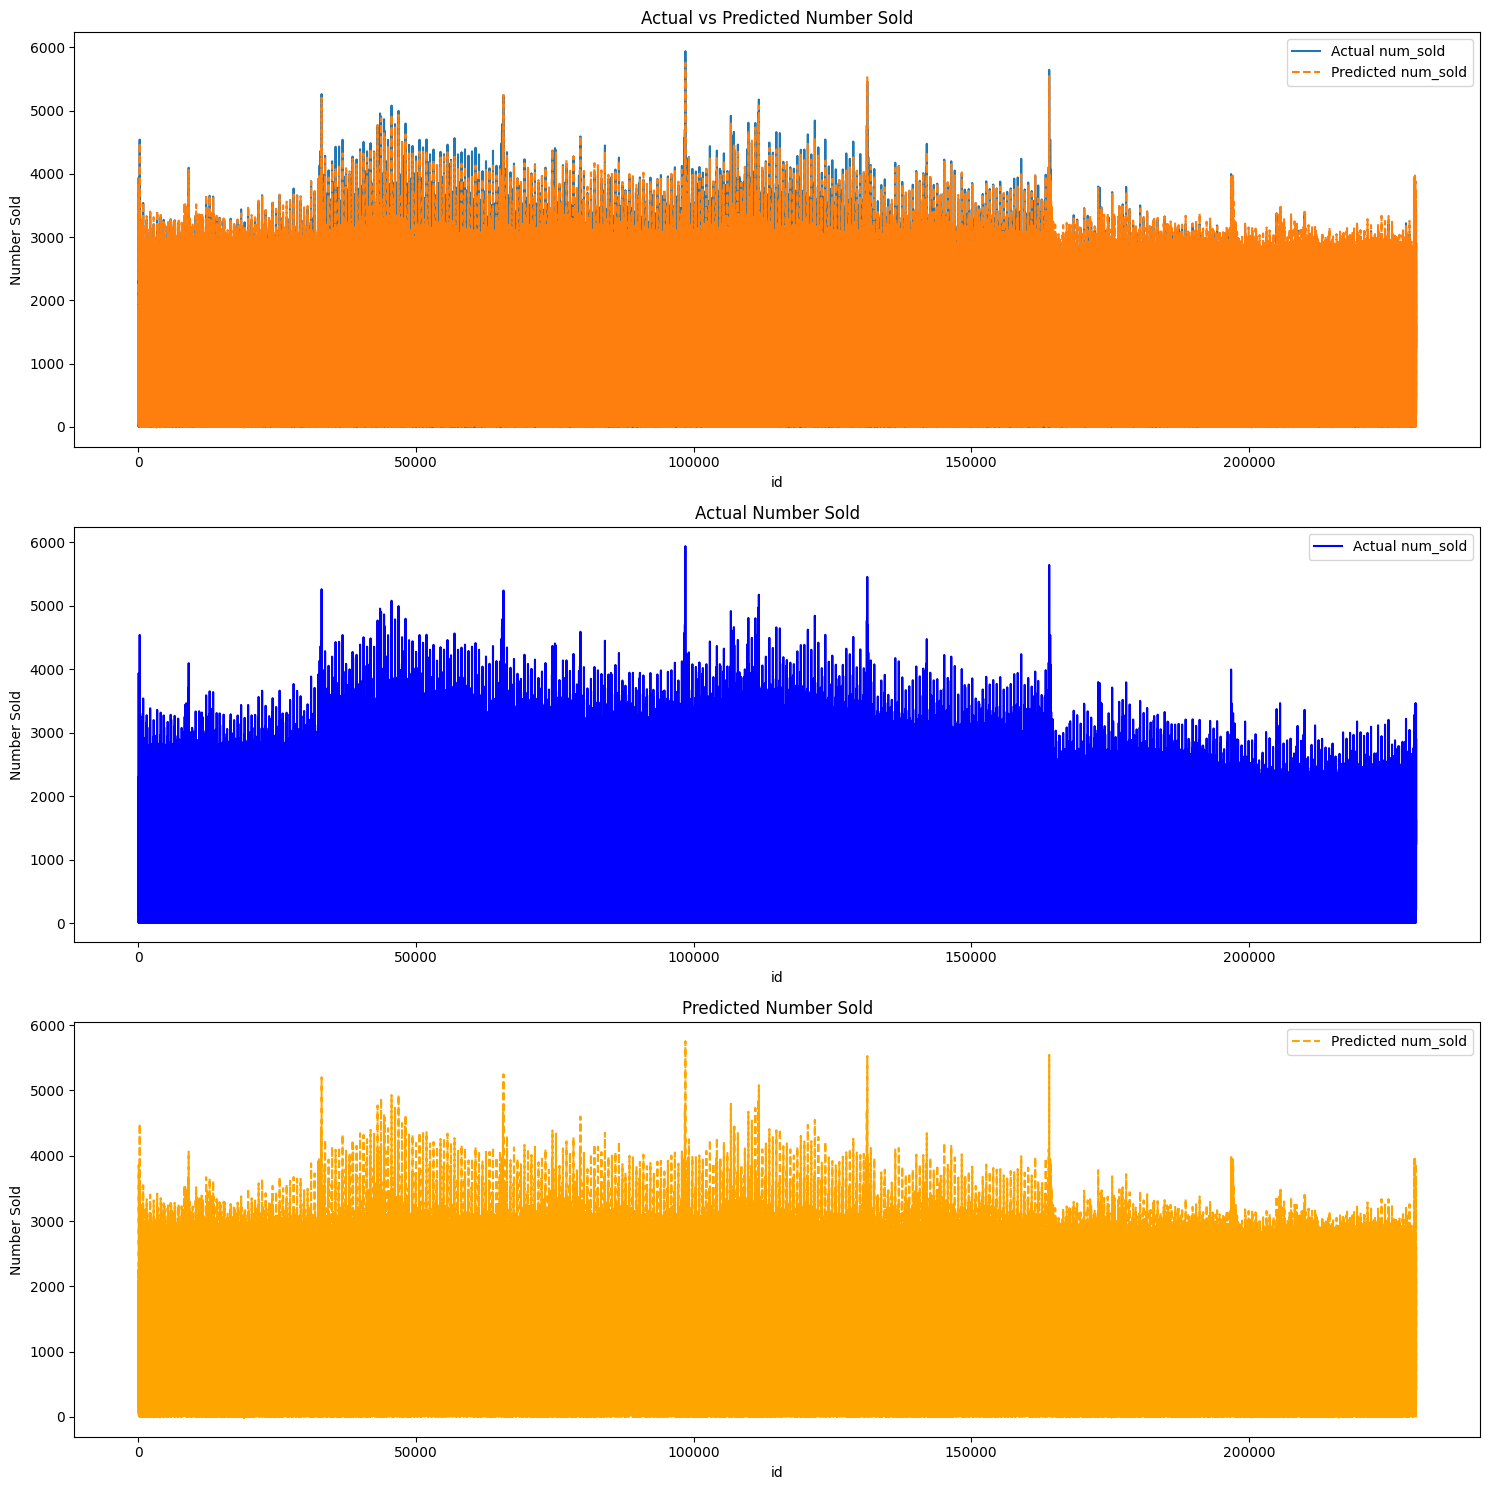

In [108]:
train_and_predict(train, 'xgb')


[I 2025-01-14 09:30:31,546] A new study created in memory with name: no-name-53ace8f6-dddb-4ab4-9fc0-3fa80913e01d
[I 2025-01-14 09:30:43,107] Trial 0 finished with value: 3.702439440611392 and parameters: {'iterations': 646, 'depth': 8, 'learning_rate': 0.001398850949321576}. Best is trial 0 with value: 3.702439440611392.
[I 2025-01-14 09:30:57,371] Trial 1 finished with value: 0.12707778033271286 and parameters: {'iterations': 592, 'depth': 9, 'learning_rate': 0.009862485045170677}. Best is trial 1 with value: 0.12707778033271286.


Best hyperparameters: {'iterations': 592, 'depth': 9, 'learning_rate': 0.009862485045170677}
There was a decimal number in the predictions.
Sum of all fractional parts: 110941.17847746558
Mean Absolute Percentage Error: 0.12561525747442967


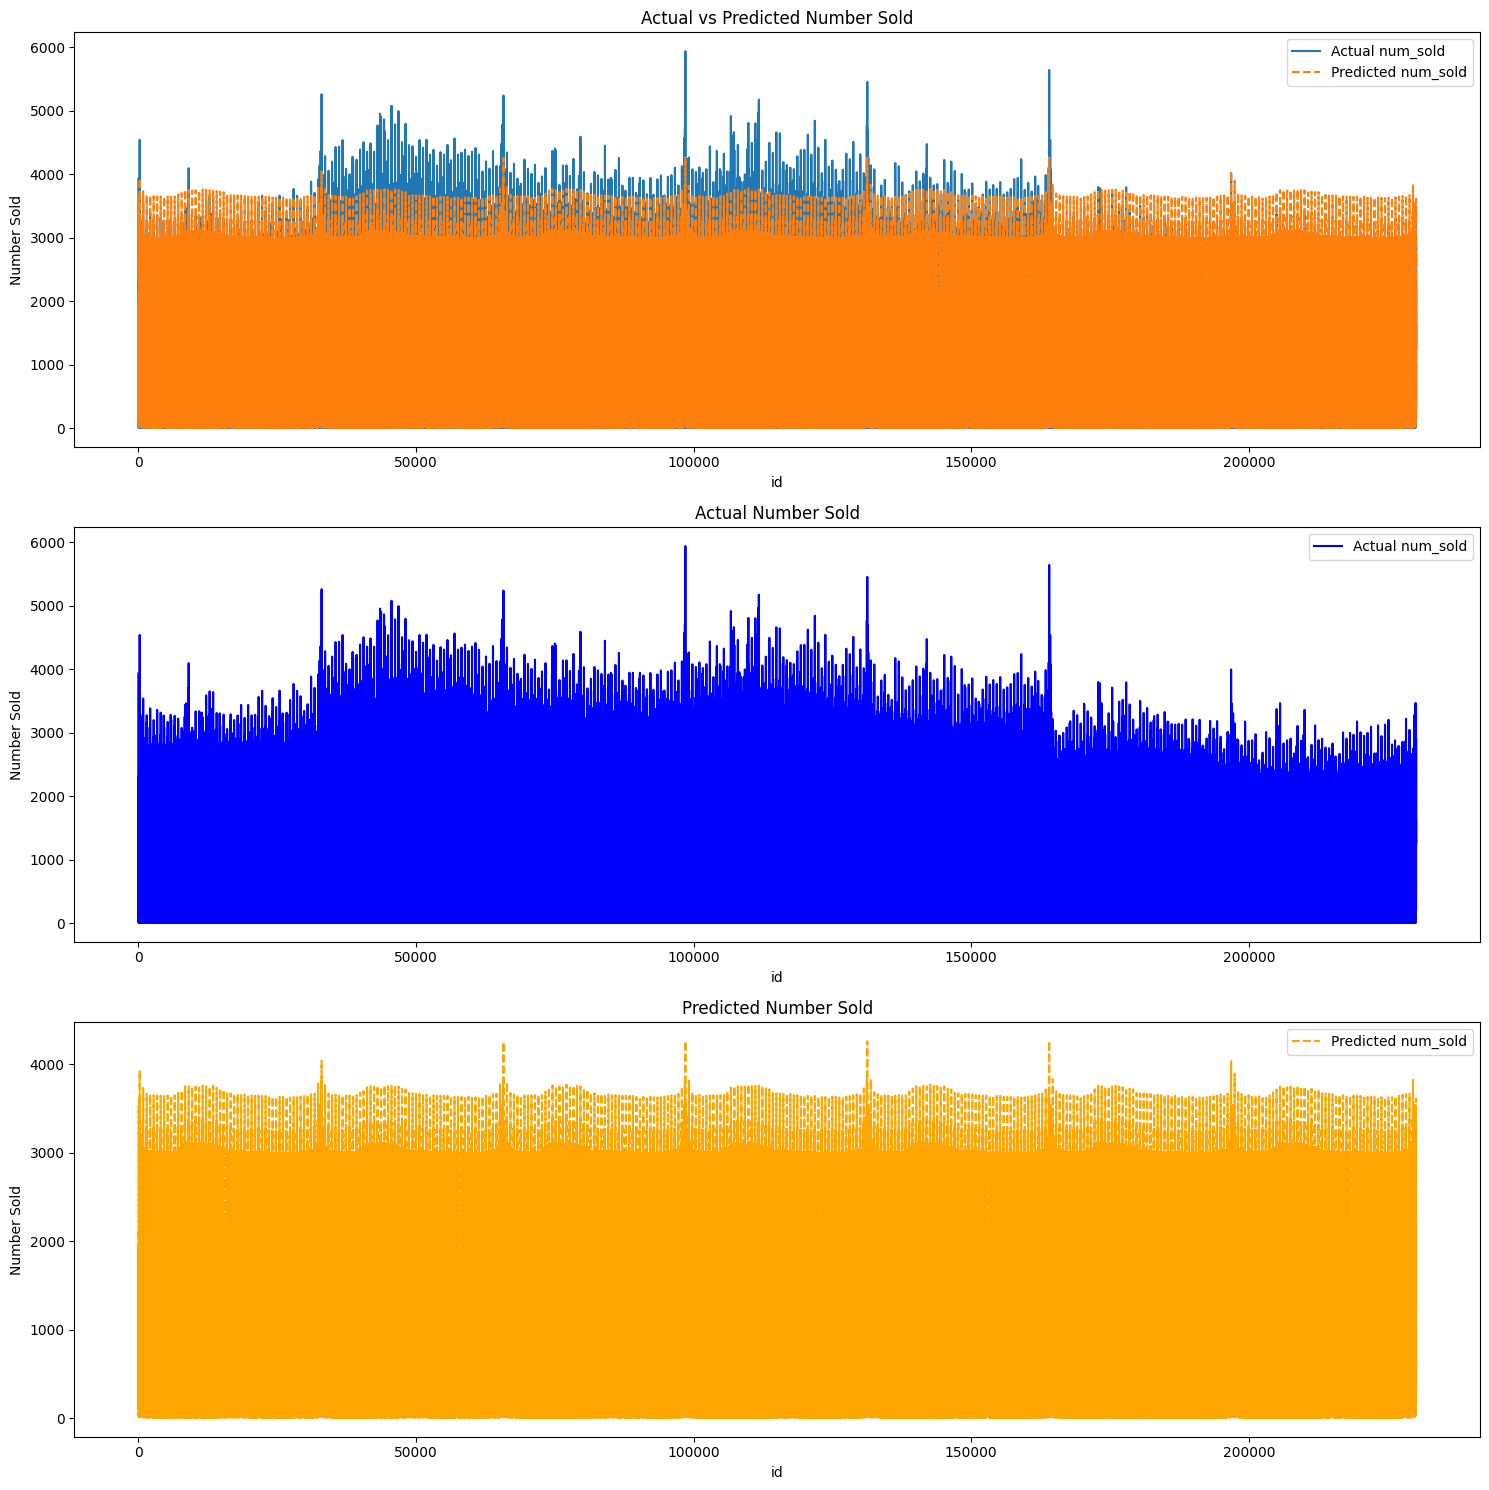

In [105]:
train_and_predict(train, 'cat')

[I 2025-01-14 09:31:17,520] A new study created in memory with name: no-name-4f392271-00f1-4708-8b6e-ab53888c1feb


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009375 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 813
[LightGBM] [Info] Number of data points in the train set: 177007, number of used features: 27
[LightGBM] [Info] Start training from score 751.724474
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

[I 2025-01-14 09:31:18,831] Trial 0 finished with value: 0.40949613324491796 and parameters: {'n_estimators': 312, 'max_depth': 4, 'learning_rate': 0.015131720501385233}. Best is trial 0 with value: 0.40949613324491796.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006892 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 813
[LightGBM] [Info] Number of data points in the train set: 177007, number of used features: 27
[LightGBM] [Info] Start training from score 751.724474
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

[I 2025-01-14 09:31:20,471] Trial 1 finished with value: 5.893733488359349 and parameters: {'n_estimators': 624, 'max_depth': 3, 'learning_rate': 0.0007449406577898375}. Best is trial 0 with value: 0.40949613324491796.


Best hyperparameters: {'n_estimators': 312, 'max_depth': 4, 'learning_rate': 0.015131720501385233}
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007009 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 813
[LightGBM] [Info] Number of data points in the train set: 221259, number of used features: 27
[LightGBM] [Info] Start training from score 752.527382
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

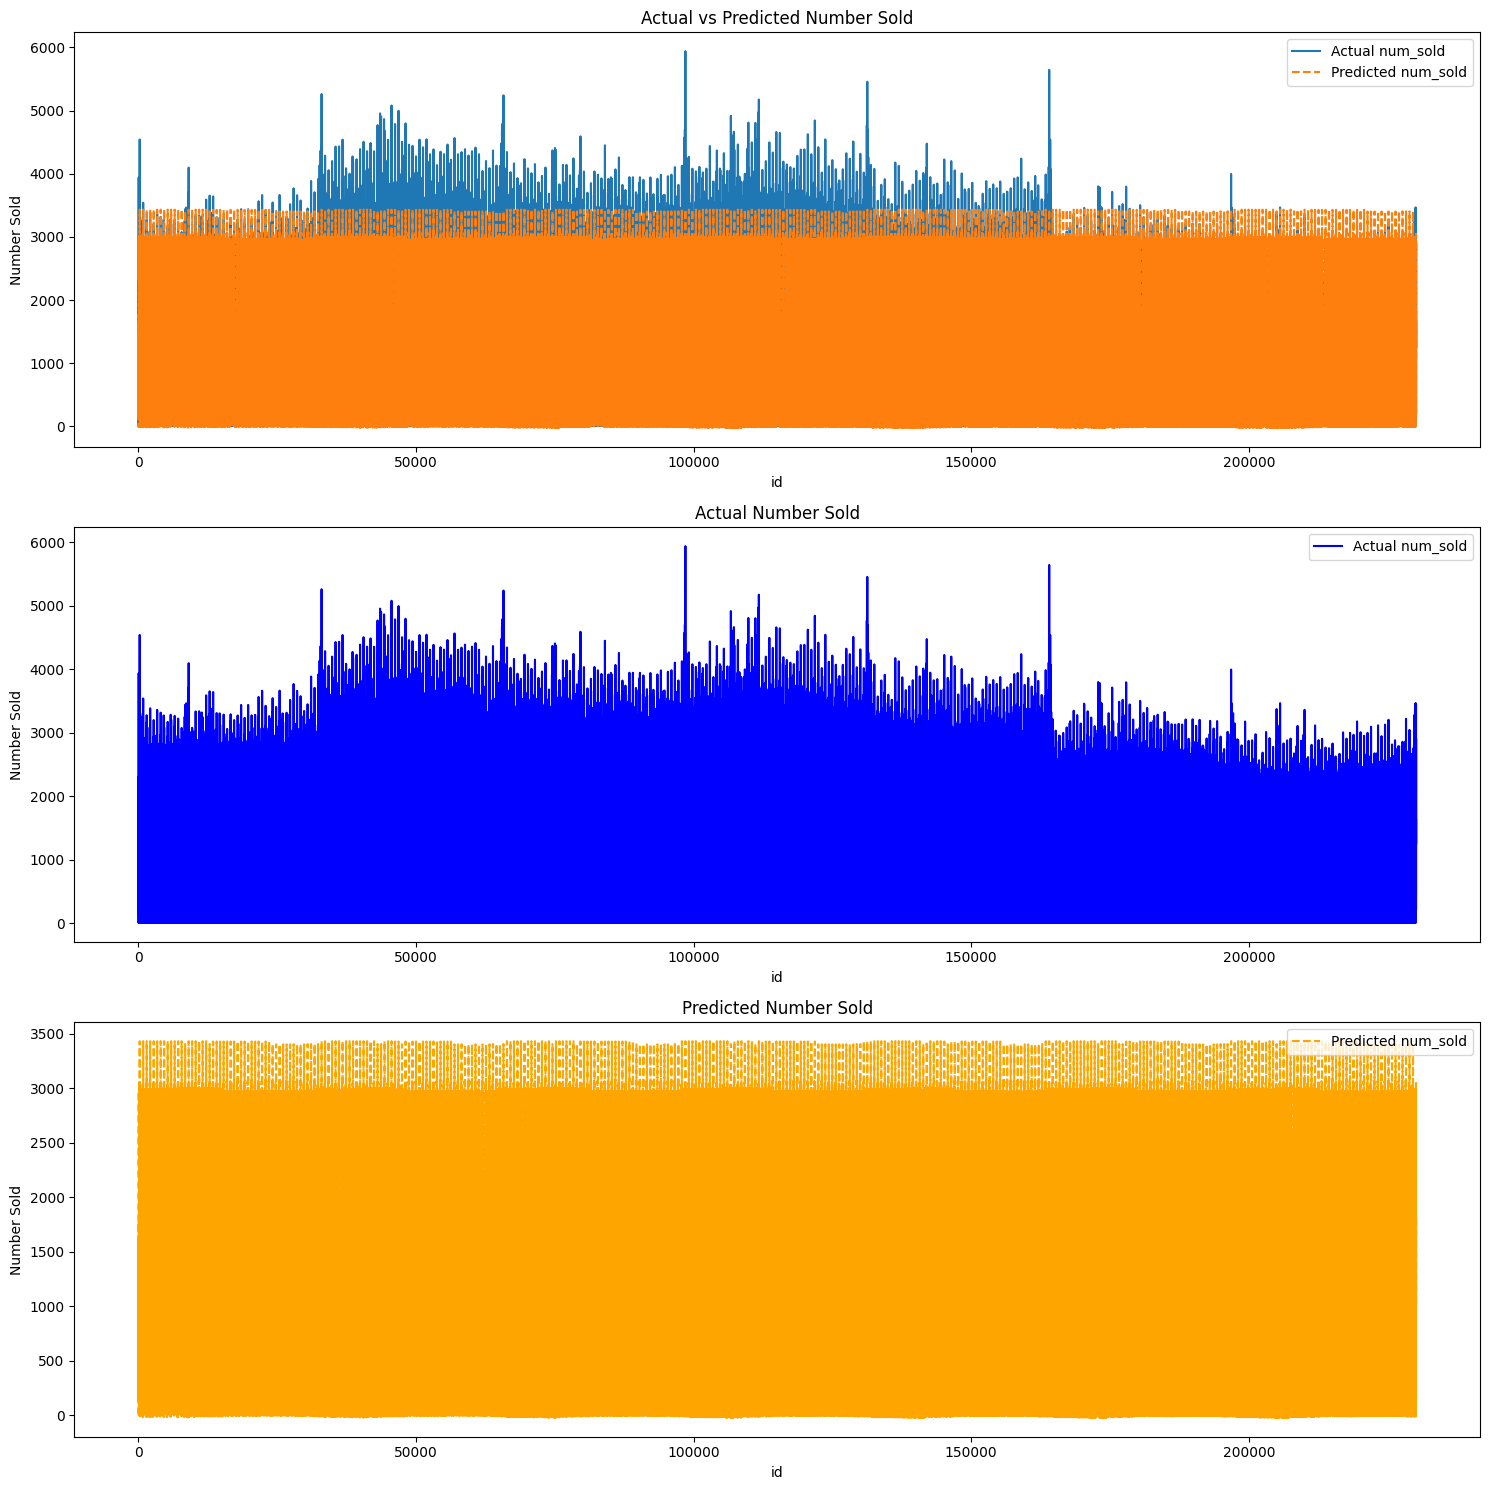

In [106]:
train_and_predict(train, 'lgbm')
